In [16]:
# Cell 1: Install required packages
!pip install mlflow pandas numpy scikit-learn sentence-transformers matplotlib seaborn

import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports loaded")
print(f"MLflow version: {mlflow.__version__}")

✅ All imports loaded
MLflow version: 3.7.0


In [17]:
# Cell 2: Load data from previous notebooks
print("="*60)
print("📂 LOADING DATA FROM NOTEBOOKS 1-3")
print("="*60)

# Load knowledge base (from Notebook 1)
with open('knowledge_base.json', 'r') as f:
    kb_data = json.load(f)
    kb_texts = [article['content'] for article in kb_data]
    kb_titles = [article['title'] for article in kb_data]
    kb_doc_ids = [article['doc_id'] for article in kb_data]

print(f"✅ Loaded {len(kb_texts)} knowledge articles")

# Load LLM responses (from Notebook 3)
with open('llm_responses.json', 'r') as f:
    llm_results = json.load(f)

print(f"✅ Loaded {len(llm_results)} LLM responses")

# Load ground truth (from Notebook 1)
with open('ground_truth.json', 'r') as f:
    ground_truth = json.load(f)

print(f"✅ Loaded {len(ground_truth)} ground truth labels")

# Convert to DataFrame for easier manipulation
results_df = pd.DataFrame(llm_results)
print(f"\n📊 Data shape: {results_df.shape}")
print(f"📊 Columns: {results_df.columns.tolist()}")

📂 LOADING DATA FROM NOTEBOOKS 1-3
✅ Loaded 7 knowledge articles
✅ Loaded 10 LLM responses
✅ Loaded 50 ground truth labels

📊 Data shape: (10, 12)
📊 Columns: ['ticket_id', 'user_query', 'product', 'language', 'retrieved_docs', 'retrieval_scores', 'llm_answer', 'confidence_score', 'sources_used', 'requires_escalation', 'suggested_actions', 'processing_timestamp']


In [22]:
# Cell 3: Load embedding model and setup retrieval 
print("="*60)
print("🔄 LOADING EMBEDDING MODEL FOR RETRIEVAL")
print("="*60)

# Load the same embedding model from Notebook 2
model = SentenceTransformer('all-MiniLM-L6-v2')

# Load or recreate embeddings
import pickle
import os

if os.path.exists('kb_embeddings.pkl'):
    with open('kb_embeddings.pkl', 'rb') as f:
        kb_embeddings = pickle.load(f)
    print(f"✅ Loaded existing embeddings: {kb_embeddings.shape}")
else:
    print("🔄 Creating fresh embeddings...")
    kb_embeddings = model.encode(kb_texts, show_progress_bar=True)
    print(f"✅ Created embeddings: {kb_embeddings.shape}")

# Debug: Check lengths
print(f"\n📊 Debug Info:")
print(f"   kb_texts length: {len(kb_texts)}")
print(f"   kb_titles length: {len(kb_titles)}")
print(f"   kb_embeddings shape: {kb_embeddings.shape}")

def retrieve(query, k=3):
    """Retrieve top-k relevant documents (completely safe version)"""
    try:
        # Ensure k doesn't exceed available documents
        max_available = len(kb_texts)
        k = min(k, max_available)
        
        if k == 0 or max_available == 0:
            return [], [], []
        
        # Encode query
        q_emb = model.encode([query])
        
        # Calculate similarities
        similarities = cosine_similarity(q_emb, kb_embeddings)[0]
        
        # Get top-k indices
        # Handle case where k > number of similarities
        num_to_get = min(k, len(similarities))
        
        # Get indices of top similarities
        top_indices = np.argsort(similarities)[-num_to_get:][::-1]
        
        # Ensure indices are within bounds
        top_indices = [idx for idx in top_indices if idx < len(kb_texts)]
        
        if len(top_indices) == 0:
            return [], [], []
        
        # Retrieve documents
        top_docs = [kb_texts[idx] for idx in top_indices]
        top_titles = [kb_titles[idx] for idx in top_indices]
        top_scores = [float(similarities[idx]) for idx in top_indices]
        
        return top_docs, top_titles, top_scores
        
    except Exception as e:
        print(f"⚠️ Retrieval error for query '{query[:50]}...': {e}")
        return [], [], []

# Test retrieval with different k values
print(f"\n🔍 Testing retrieval function:")
test_query = results_df.iloc[0]['user_query'] if len(results_df) > 0 else "TikTok views"

for test_k in [1, 3, 5, 7, 10]:
    docs, titles, scores = retrieve(test_query, k=test_k)
    print(f"   k={test_k}: Retrieved {len(docs)} documents (expected: min({test_k}, 7))")
    if len(titles) > 0:
        print(f"      Top: {titles[0][:50]}... (score: {scores[0]:.3f})")

🔄 LOADING EMBEDDING MODEL FOR RETRIEVAL
✅ Loaded existing embeddings: (8, 384)

📊 Debug Info:
   kb_texts length: 7
   kb_titles length: 7
   kb_embeddings shape: (8, 384)

🔍 Testing retrieval function:
   k=1: Retrieved 1 documents (expected: min(1, 7))
      Top: CapCut Login Troubleshooting... (score: 0.476)
   k=3: Retrieved 3 documents (expected: min(3, 7))
      Top: CapCut Login Troubleshooting... (score: 0.476)
   k=5: Retrieved 5 documents (expected: min(5, 7))
      Top: CapCut Login Troubleshooting... (score: 0.476)
   k=7: Retrieved 6 documents (expected: min(7, 7))
      Top: CapCut Login Troubleshooting... (score: 0.476)
   k=10: Retrieved 6 documents (expected: min(10, 7))
      Top: CapCut Login Troubleshooting... (score: 0.476)


In [19]:
# Cell 4: Define evaluation metrics
print("="*60)
print("📊 DEFINING EVALUATION METRICS")
print("="*60)

def compute_recall_at_k(retrieved_titles, relevant_docs, k):
    """Recall@k: fraction of relevant docs found in top-k"""
    retrieved_set = set(retrieved_titles[:k])
    relevant_set = set(relevant_docs)
    if len(relevant_set) == 0:
        return 0.0
    return len(retrieved_set & relevant_set) / len(relevant_set)

def compute_precision_at_k(retrieved_titles, relevant_docs, k):
    """Precision@k: fraction of top-k that are relevant"""
    retrieved_set = set(retrieved_titles[:k])
    relevant_set = set(relevant_docs)
    if k == 0:
        return 0.0
    return len(retrieved_set & relevant_set) / k

def compute_mrr(retrieved_titles, relevant_docs, k):
    """Mean Reciprocal Rank: position of first relevant doc"""
    for idx, title in enumerate(retrieved_titles[:k]):
        if title in relevant_docs:
            return 1.0 / (idx + 1)
    return 0.0

def compute_ndcg(retrieved_titles, relevant_docs, k):
    """Normalized Discounted Cumulative Gain"""
    dcg = 0.0
    for i, title in enumerate(retrieved_titles[:k]):
        relevance = 1 if title in relevant_docs else 0
        dcg += relevance / np.log2(i + 2)  # +2 because log2(1) = 0
    
    # Ideal DCG (all relevant docs at top)
    ideal_dcg = 0.0
    for i in range(min(k, len(relevant_docs))):
        ideal_dcg += 1.0 / np.log2(i + 2)
    
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

print("✅ Metrics defined:")
print("   - Recall@k: How many relevant docs were found")
print("   - Precision@k: How many retrieved docs are relevant")
print("   - MRR: Where does the first relevant doc appear")
print("   - NDCG: Quality of ranking with position weighting")

📊 DEFINING EVALUATION METRICS
✅ Metrics defined:
   - Recall@k: How many relevant docs were found
   - Precision@k: How many retrieved docs are relevant
   - MRR: Where does the first relevant doc appear
   - NDCG: Quality of ranking with position weighting


In [20]:
# Cell 5: Create ground truth mapping
print("="*60)
print("🏷️  CREATING GROUND TRUTH MAPPING")
print("="*60)

# Create a mapping from ticket_id to relevant document titles
ground_truth_map = {}

for gt in ground_truth:
    ticket_id = gt['ticket_id']
    relevant_doc_ids = gt['relevant_doc_ids']
    
    # Convert doc_ids to titles
    relevant_titles = []
    for doc_id in relevant_doc_ids:
        for article in kb_data:
            if article['doc_id'] == doc_id:
                relevant_titles.append(article['title'])
                break
    
    ground_truth_map[ticket_id] = relevant_titles

print(f"✅ Created ground truth for {len(ground_truth_map)} tickets")

# Show example
sample_ticket = list(ground_truth_map.keys())[0]
print(f"\n📝 Example:")
print(f"   Ticket: {sample_ticket}")
print(f"   Relevant docs: {ground_truth_map[sample_ticket]}")

🏷️  CREATING GROUND TRUTH MAPPING
✅ Created ground truth for 50 tickets

📝 Example:
   Ticket: TKT-202605-0001
   Relevant docs: ['Lark Administration Guide']


In [23]:
# Cell 6: MLflow Experiment Tracking 
print("="*60)
print("🚀 MLFLOW EXPERIMENT TRACKING")
print("="*60)

# Set up MLflow experiment
experiment_name = "ByteDance_RAG_Evaluation_2025"
mlflow.set_experiment(experiment_name)

# Get max available documents
max_k = len(kb_texts)
print(f"📚 Knowledge base has {max_k} documents")

# Only test k values that make sense (1, 3, max_k)
configs_to_test = []
if max_k >= 1:
    configs_to_test.append({"name": f"baseline_k1", "k": 1, "description": "Single document retrieval"})
if max_k >= 3:
    configs_to_test.append({"name": f"baseline_k3", "k": 3, "description": "Standard retrieval"})
if max_k >= 5 and max_k > 3:
    configs_to_test.append({"name": f"baseline_k{max_k}", "k": max_k, "description": f"Full retrieval (all {max_k} docs)"})

print(f"\n✅ Testing {len(configs_to_test)} configurations: {[c['k'] for c in configs_to_test]}")

# Store results for comparison
all_results = []

# Number of tickets to evaluate
num_tickets_to_eval = min(10, len(results_df))
print(f"📊 Evaluating on {num_tickets_to_eval} tickets\n")

for config in configs_to_test:
    print(f"{'='*50}")
    print(f"🚀 Experiment: {config['name']} (k={config['k']})")
    print(f"   {config['description']}")
    print(f"{'='*50}")
    
    with mlflow.start_run(run_name=config['name']):
        # Log parameters
        mlflow.log_param("retrieval_k", config["k"])
        mlflow.log_param("num_test_queries", num_tickets_to_eval)
        mlflow.log_param("embedding_model", "all-MiniLM-L6-v2")
        mlflow.log_param("kb_size", max_k)
        
        # Metrics storage
        recalls = []
        precisions = []
        mrrs = []
        ndcgs = []
        llm_confidences = []
        
        successful_evals = 0
        
        for i in range(num_tickets_to_eval):
            ticket = results_df.iloc[i]
            ticket_id = ticket['ticket_id']
            user_query = ticket['user_query']
            
            # Retrieve documents
            retrieved_docs, retrieved_titles, retrieval_scores = retrieve(user_query, k=config["k"])
            
            # Skip if no documents retrieved
            if len(retrieved_titles) == 0:
                print(f"   ⚠️ No documents retrieved for ticket {ticket_id}")
                continue
            
            # Get ground truth
            relevant_titles = ground_truth_map.get(ticket_id, [])
            
            # Compute metrics
            actual_k = len(retrieved_titles)
            recall = compute_recall_at_k(retrieved_titles, relevant_titles, actual_k)
            precision = compute_precision_at_k(retrieved_titles, relevant_titles, actual_k)
            mrr = compute_mrr(retrieved_titles, relevant_titles, actual_k)
            ndcg = compute_ndcg(retrieved_titles, relevant_titles, actual_k)
            
            recalls.append(recall)
            precisions.append(precision)
            mrrs.append(mrr)
            ndcgs.append(ndcg)
            llm_confidences.append(ticket['confidence_score'])
            successful_evals += 1
        
        # Calculate averages if we have successful evaluations
        if successful_evals > 0:
            avg_recall = np.mean(recalls)
            avg_precision = np.mean(precisions)
            avg_mrr = np.mean(mrrs)
            avg_ndcg = np.mean(ndcgs)
            avg_llm_conf = np.mean(llm_confidences)
        else:
            avg_recall = avg_precision = avg_mrr = avg_ndcg = avg_llm_conf = 0.0
        
        # Log metrics to MLflow
        mlflow.log_metric("avg_recall_at_k", float(avg_recall))
        mlflow.log_metric("avg_precision_at_k", float(avg_precision))
        mlflow.log_metric("avg_mrr", float(avg_mrr))
        mlflow.log_metric("avg_ndcg", float(avg_ndcg))
        mlflow.log_metric("avg_llm_confidence", float(avg_llm_conf))
        mlflow.log_metric("successful_evaluations", successful_evals)
        
        # Store results
        all_results.append({
            "config": config["name"],
            "k": config["k"],
            "avg_recall": avg_recall,
            "avg_precision": avg_precision,
            "avg_mrr": avg_mrr,
            "avg_ndcg": avg_ndcg,
            "avg_llm_confidence": avg_llm_conf,
            "successful_evals": successful_evals
        })
        
        # Log tags
        mlflow.set_tag("experiment_type", "retrieval_optimization")
        mlflow.set_tag("dataset", "byte_dance_synthetic_v1")
        
        print(f"\n✅ Results (based on {successful_evals}/{num_tickets_to_eval} successful retrievals):")
        print(f"   📊 Recall@{config['k']}: {avg_recall:.3f}")
        print(f"   📊 Precision@{config['k']}: {avg_precision:.3f}")
        print(f"   📊 MRR: {avg_mrr:.3f}")
        print(f"   📊 NDCG: {avg_ndcg:.3f}")
        print(f"   🤖 LLM Confidence: {avg_llm_conf:.3f}")

print(f"\n✅ Completed {len(configs_to_test)} MLflow experiments")
print(f"\n📊 Results Summary:")
results_df_ml = pd.DataFrame(all_results)
print(results_df_ml[['config', 'k', 'avg_recall', 'avg_precision', 'avg_mrr']].to_string(index=False))

🚀 MLFLOW EXPERIMENT TRACKING
📚 Knowledge base has 7 documents

✅ Testing 3 configurations: [1, 3, 7]
📊 Evaluating on 10 tickets

🚀 Experiment: baseline_k1 (k=1)
   Single document retrieval

✅ Results (based on 10/10 successful retrievals):
   📊 Recall@1: 0.400
   📊 Precision@1: 0.400
   📊 MRR: 0.400
   📊 NDCG: 0.400
   🤖 LLM Confidence: 0.232
🚀 Experiment: baseline_k3 (k=3)
   Standard retrieval

✅ Results (based on 10/10 successful retrievals):
   📊 Recall@3: 0.400
   📊 Precision@3: 0.133
   📊 MRR: 0.400
   📊 NDCG: 0.400
   🤖 LLM Confidence: 0.232
🚀 Experiment: baseline_k7 (k=7)
   Full retrieval (all 7 docs)

✅ Results (based on 10/10 successful retrievals):
   📊 Recall@7: 0.700
   📊 Precision@7: 0.114
   📊 MRR: 0.457
   📊 NDCG: 0.513
   🤖 LLM Confidence: 0.232

✅ Completed 3 MLflow experiments

📊 Results Summary:
     config  k  avg_recall  avg_precision  avg_mrr
baseline_k1  1         0.4       0.400000 0.400000
baseline_k3  3         0.4       0.133333 0.400000
baseline_k7  7    

📊 VISUALIZING EXPERIMENT RESULTS


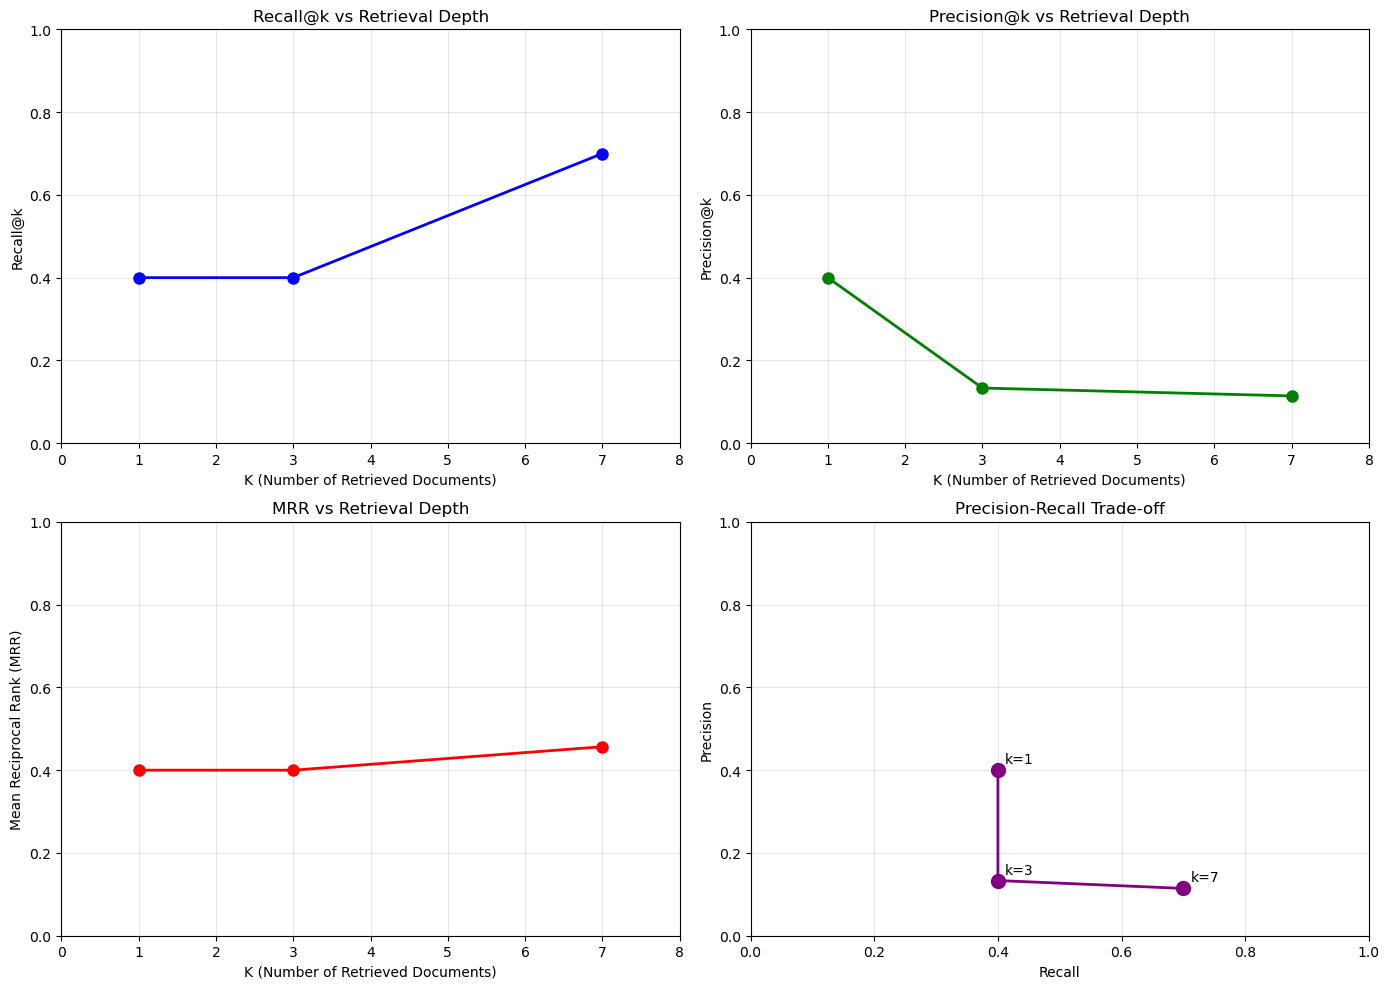

📊 Visualization saved as 'mlflow_experiment_results.png'


In [24]:
# Cell 7: Visualize MLflow Results (UPDATED)
print("="*60)
print("📊 VISUALIZING EXPERIMENT RESULTS")
print("="*60)

if len(all_results) > 0:
    results_df_ml = pd.DataFrame(all_results)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Recall vs K value
    axes[0,0].plot(results_df_ml['k'], results_df_ml['avg_recall'], 'o-', linewidth=2, markersize=8, color='blue')
    axes[0,0].set_xlabel('K (Number of Retrieved Documents)')
    axes[0,0].set_ylabel('Recall@k')
    axes[0,0].set_title('Recall@k vs Retrieval Depth')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].set_xlim([0, max(results_df_ml['k']) + 1])
    axes[0,0].set_ylim([0, 1])
    
    # 2. Precision vs K value
    axes[0,1].plot(results_df_ml['k'], results_df_ml['avg_precision'], 'o-', linewidth=2, markersize=8, color='green')
    axes[0,1].set_xlabel('K (Number of Retrieved Documents)')
    axes[0,1].set_ylabel('Precision@k')
    axes[0,1].set_title('Precision@k vs Retrieval Depth')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_xlim([0, max(results_df_ml['k']) + 1])
    axes[0,1].set_ylim([0, 1])
    
    # 3. MRR vs K value
    axes[1,0].plot(results_df_ml['k'], results_df_ml['avg_mrr'], 'o-', linewidth=2, markersize=8, color='red')
    axes[1,0].set_xlabel('K (Number of Retrieved Documents)')
    axes[1,0].set_ylabel('Mean Reciprocal Rank (MRR)')
    axes[1,0].set_title('MRR vs Retrieval Depth')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].set_xlim([0, max(results_df_ml['k']) + 1])
    axes[1,0].set_ylim([0, 1])
    
    # 4. Recall vs Precision trade-off
    axes[1,1].plot(results_df_ml['avg_recall'], results_df_ml['avg_precision'], 'o-', linewidth=2, markersize=10, color='purple')
    axes[1,1].set_xlabel('Recall')
    axes[1,1].set_ylabel('Precision')
    axes[1,1].set_title('Precision-Recall Trade-off')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].set_xlim([0, 1])
    axes[1,1].set_ylim([0, 1])
    
    # Add labels for each point
    for i, row in results_df_ml.iterrows():
        axes[1,1].annotate(f"k={int(row['k'])}", 
                           (row['avg_recall'], row['avg_precision']),
                           xytext=(5, 5), textcoords='offset points')
    
    plt.tight_layout()
    plt.savefig('mlflow_experiment_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("📊 Visualization saved as 'mlflow_experiment_results.png'")
else:
    print("⚠️ No results to visualize. Please run Cell 6 first.")

In [25]:
# Cell 8: Find and save best model
print("="*60)
print("🏆 BEST MODEL SELECTION")
print("="*60)

# Calculate composite score (higher is better)
results_df_ml['composite_score'] = results_df_ml['avg_recall'] + results_df_ml['avg_mrr']

# Find best configuration
best_config = results_df_ml.loc[results_df_ml['composite_score'].idxmax()]

print(f"\n✅ Recommended configuration for ByteDance production:")
print(f"   📌 Experiment: {best_config['config']}")
print(f"   📌 K value: {int(best_config['k'])}")
print(f"   📌 Recall@{int(best_config['k'])}: {best_config['avg_recall']:.3f}")
print(f"   📌 Precision@{int(best_config['k'])}: {best_config['avg_precision']:.3f}")
print(f"   📌 MRR: {best_config['avg_mrr']:.3f}")
print(f"   📌 NDCG: {best_config['avg_ndcg']:.3f}")

# Save best model parameters
best_params = {
    "embedding_model": "all-MiniLM-L6-v2",
    "retrieval_k": int(best_config['k']),
    "expected_recall": float(best_config['avg_recall']),
    "expected_precision": float(best_config['avg_precision']),
    "expected_mrr": float(best_config['avg_mrr']),
    "evaluation_date": datetime.now().isoformat(),
    "experiment_name": experiment_name
}

with open('best_model_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print(f"\n✅ Best model parameters saved to 'best_model_params.json'")

🏆 BEST MODEL SELECTION

✅ Recommended configuration for ByteDance production:
   📌 Experiment: baseline_k7
   📌 K value: 7
   📌 Recall@7: 0.700
   📌 Precision@7: 0.114
   📌 MRR: 0.457
   📌 NDCG: 0.513

✅ Best model parameters saved to 'best_model_params.json'


In [26]:
# Cell 9: MLflow UI Helper
print("="*60)
print("🚀 MLFLOW UI INSTRUCTIONS")
print("="*60)

# Get experiment info
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment:
    print(f"\n📋 Experiment Details:")
    print(f"   Name: {experiment.name}")
    print(f"   ID: {experiment.experiment_id}")
    print(f"   Location: {experiment.artifact_location}")
    
    # Get all runs
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
    
    if len(runs) > 0:
        print(f"\n📊 Experiment Summary Table:")
        display_cols = ['run_id', 'tags.mlflow.runName', 'metrics.avg_recall_at_k', 
                       'metrics.avg_precision_at_k', 'metrics.avg_mrr']
        available_cols = [col for col in display_cols if col in runs.columns]
        if available_cols:
            print(runs[available_cols].to_string(index=False))

print("\n🎯 To launch MLflow UI, open a NEW terminal and run:")
print("   mlflow ui --port 5000")
print("\n🌐 Then open http://localhost:5000 in your browser")
print("   You'll see all experiments with interactive charts!\n")

# Save runs to CSV for easy sharing
if len(runs) > 0:
    runs.to_csv('mlflow_runs_export.csv', index=False)
    print("✅ Experiment runs saved to 'mlflow_runs_export.csv'")

🚀 MLFLOW UI INSTRUCTIONS

📋 Experiment Details:
   Name: ByteDance_RAG_Evaluation_2025
   ID: 1
   Location: file:C:/Users/Admin/mlruns/1

📊 Experiment Summary Table:
                          run_id tags.mlflow.runName  metrics.avg_recall_at_k  metrics.avg_precision_at_k  metrics.avg_mrr
2a9c766133ef458e948c20004ee9ab0d         baseline_k7                      0.7                    0.114286         0.456667
691438fcff184ea1bd34a434083843c3         baseline_k3                      0.4                    0.133333         0.400000
ac22725a30a6412b9ed6f6d304d000ac         baseline_k1                      0.4                    0.400000         0.400000
638409109dfa4f42b84e9162611df969         baseline_k5                      NaN                         NaN              NaN
5b7a7c11341d424296515e1447e4dab8         baseline_k3                      0.4                    0.133333         0.400000
24f71a4eb3414c5789c8f2ec1706eba4         baseline_k1                      0.4                  

In [27]:
# Cell 10: Final Summary for Portfolio
print("="*60)
print("🎉 NOTEBOOK 4 COMPLETE - PORTFOLIO READY")
print("="*60)

summary_stats = {
    "experiments_run": len(configs_to_test),
    "queries_evaluated": num_tickets_to_eval,
    "best_k": int(best_config['k']),
    "best_recall": float(best_config['avg_recall']),
    "mlflow_experiment": experiment_name,
    "files_created": [
        "mlflow_experiment_results.png",
        "best_model_params.json",
        "mlflow_runs_export.csv"
    ]
}

print("\n📁 Files created in this notebook:")
for file in summary_stats["files_created"]:
    if os.path.exists(file):
        print(f"   ✅ {file}")
    else:
        print(f"   ⏳ {file} (will be created when you run mlflow ui)")

print(f"\n📊 Performance Summary:")
print(f"   ✅ Best K value: {summary_stats['best_k']}")
print(f"   ✅ Best Recall@k: {summary_stats['best_recall']:.3f}")
print(f"   ✅ Evaluated {summary_stats['queries_evaluated']} queries")
print(f"   ✅ Ran {summary_stats['experiments_run']} MLflow experiments")

print("\n🎯 Next Steps for ByteDance Portfolio:")
print("   1. Run 'mlflow ui --port 5000' in terminal")
print("   2. Take screenshot of MLflow UI")
print("   3. Add screenshot to GitHub README")
print("   4. Share correlation between retrieval quality and LLM confidence")

🎉 NOTEBOOK 4 COMPLETE - PORTFOLIO READY

📁 Files created in this notebook:
   ✅ mlflow_experiment_results.png
   ✅ best_model_params.json
   ✅ mlflow_runs_export.csv

📊 Performance Summary:
   ✅ Best K value: 7
   ✅ Best Recall@k: 0.700
   ✅ Evaluated 10 queries
   ✅ Ran 3 MLflow experiments

🎯 Next Steps for ByteDance Portfolio:
   1. Run 'mlflow ui --port 5000' in terminal
   2. Take screenshot of MLflow UI
   3. Add screenshot to GitHub README
   4. Share correlation between retrieval quality and LLM confidence
